In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Dataset de ejemplo
data = pd.DataFrame({
    "Agua": [300, 280, 310, 290, 305, 315, 295, 285, 320, 330],
    "Gasolina": [150, 160, 170, 180, 175, 165, 155, 162, 172, 185],
    "Luz": [200, 210, 190, 205, 195, 215, 185, 225, 198, 202],
    "Renta": [5000]*10,
    "Super": [1200, 1300, 1100, 1250, 1280, 1180, 1220, 1260, 1240, 1210],
    "Total": [6850, 6980, 6770, 6925, 6955, 7075, 6855, 6990, 7130, 7050]
})

X = data.drop("Total", axis=1)
y = data["Total"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [2]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
print("Score Árbol:", tree.score(X_test, y_test))


Score Árbol: -7.680414857694162


In [3]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=100,   # número de árboles
    max_depth=3,       # profundidad máxima de cada árbol
    random_state=42
)

forest.fit(X_train, y_train)
print("Score Random Forest:", forest.score(X_test, y_test))


Score Random Forest: -5.8474784400627025


In [4]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_forest = forest.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_forest))

print("Random Forest RMSE:", rmse)


Random Forest RMSE: 162.13176400836122


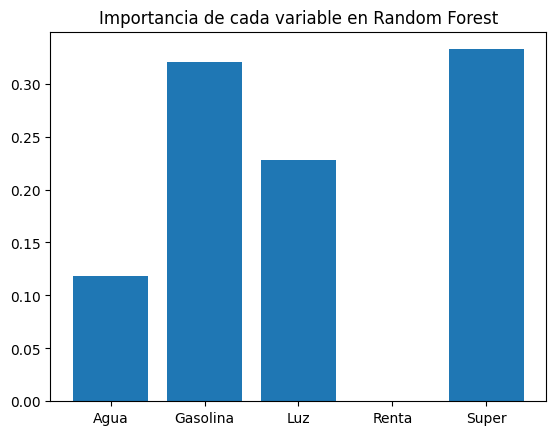

In [5]:
import matplotlib.pyplot as plt

importances = forest.feature_importances_
plt.bar(X.columns, importances)
plt.title("Importancia de cada variable en Random Forest")
plt.show()
